# Промышленность

## Описание проекта

Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали.  
Для этого комбинату нужно контролировать температуру сплава.  
Задача — построить модель, которая будет её предсказывать.  
Заказчик хочет использовать разработанную модель для имитации технологического процесса.  

## Описание процесса обработки

Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн.  
Чтобы ковш выдерживал высокие температуры, изнутри его облицовывают огнеупорным кирпичом.  
Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами. Они установлены на крышке ковша.  
Сначала происходит десульфурация — из стали выводят серу и корректируют её химический состав добавлением примесей.  
Затем сталь легируют — добавляют в неё куски сплава из бункера для сыпучих материалов или порошковую проволоку через специальный трайб-аппарат.  
Прежде чем в первый раз ввести легирующие добавки, специалисты производят химический анализ стали и измеряют её температуру.  
Потом температуру на несколько минут повышают, уже после этого добавляют легирующие материалы и продувают сталь инертным газом, чтобы перемешать, а затем снова проводят измерения.  
Такой цикл повторяется до тех пор, пока не будут достигнуты нужный химический состав стали и оптимальная температура плавки.  
Дальше расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки.  
Оттуда готовый продукт выходит в виде заготовок-слябов (англ. slab, «плита»).

## Описание данных

Данные хранятся в Sqlite  — СУБД, в которой база данных представлена одним файлом.  
Она состоит из нескольких таблиц:  
- steel.data_arc — данные об электродах;  
- steel.data_bulk — данные об объёме сыпучих материалов;  
- steel.data_bulk_time — данные о времени подачи сыпучих материалов;  
- steel.data_gas — данные о продувке сплава газом;  
- steel.data_temp — данные об измерениях температуры;  
- steel.data_wire — данные об объёме проволочных материалов;  
- steel.data_wire_time — данные о времени подачи проволочных материалов.  

Таблица steel.data_arc  
- key — номер партии;
- BeginHeat — время начала нагрева;
- EndHeat — время окончания нагрева;
- ActivePower — значение активной мощности;
- ReactivePower — значение реактивной мощности.

Таблица steel.data_bulk
- key — номер партии;
- Bulk1 … Bulk15 — объём подаваемого материала.  

Таблица steel.data_bulk_time  
- key — номер партии;
- Bulk1 … Bulk15 — время подачи материала.

Таблица steel.data_gas
- key — номер партии;
- gas — объём подаваемого газа.

Таблица steel.data_temp
- key — номер партии;
- MesaureTime — время замера;
- Temperature — значение температуры.

Таблица steel.data_wire
- key — номер партии;
- Wire1 … Wire9 — объём подаваемых проволочных материалов.

Таблица steel.data_wire_time
- key — номер партии;
- Wire1 … Wire9 — время подачи проволочных материалов.  

Во всех файлах столбец key содержит номер партии.  
В таблицах может быть несколько строк с одинаковым значением key: они соответствуют разным итерациям обработки.

# Проектирование

## Импорты

In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine, inspect, Table, MetaData
from sqlalchemy.orm import sessionmaker
import logging
import warnings
import seaborn as sns
import numpy as np

import re
import missingno as msno
import matplotlib.pyplot as plt
from IPython.display import HTML, display

# ============================================
# НАСТРОЙКИ ЛОГИРОВАНИЯ И ПРЕДУПРЕЖДЕНИЙ
# ============================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

# Отключаем лишние предупреждения
warnings.filterwarnings("ignore")

## Константы

In [2]:
BD = '../data/ds-plus-final.db'
RANDOM_STATE = 10326

## Функции проекта

In [3]:
# сделаем функцию оценки пропусков в датасетах
def missing_data(data):
    missing_data = data.isna().sum()
    missing_data = missing_data[missing_data > 0]
    display(missing_data)


# функция для обработки пробелов
def process_spaces(s):
    if isinstance(s, str):
        s = s.strip()
        s = " ".join(s.split())
    return s


# замена пробелов на нижнее подчеркинвание в названии столбцов
def replace_spaces(s):
    if isinstance(s, str):
        s = s.strip()
        s = "_".join(s.split())
    return s


def drop_duplicated(data):
    # проверка дубликатов
    logger.info("Проверим дубликаты и удалим, если есть")
    num_duplicates = data.duplicated().sum()
    display(num_duplicates)

    if num_duplicates > 0:
        logger.info("Удаляем")
        data = data.drop_duplicates(keep="first").reset_index(
            drop=True
        )  # обновляем DataFrame
    else:
        logger.info("Дубликаты отсутствуют")
    return data


def normalize_columns(columns):
    new_cols = []
    for col in columns:
        # вставляем "_" перед заглавной буквой (латиница или кириллица), кроме первой
        col = re.sub(r"(?<!^)(?=[A-ZА-ЯЁ])", "_", col)
        # приводим к нижнему регистру
        col = col.lower()
        new_cols.append(col)
    return new_cols


def check_data(data):
    # приведем все к нижнему регистру
    data.columns = normalize_columns(data.columns)

    # удалим лишние пробелы в строках
    for col in data.columns:
        if data[col].dtype == "object":
            data[col] = data[col].apply(
                lambda x: process_spaces(x) if isinstance(x, str) else x
            )

    # и в названии столбцов
    data.columns = [replace_spaces(col) for col in data.columns]

    # строки в ячейках строчными буквами
    for col in data.columns:
        if data[col].dtype == "object":
            # Безопасное преобразование: только для строк, игнорируем None и не-строки
            data[col] = data[col].apply(
                lambda x: x.lower() if isinstance(x, str) else x
            )

    # общая информация
    logger.info("Общая информация базы данных")
    display(data.info())

    # 5 строк
    logger.info("5 случайных строк")
    display(data.sample(5))

    # пропуски
    logger.info("Число пропусков в базе данных")
    display(missing_data(data))

    # проверка на наличие пропусков
    if data.isnull().sum().sum() > 0:
        logger.info("Визуализация пропусков")
        msno.bar(data)
        plt.show()

    # средние характеристики
    logger.info("Характеристики базы данных")
    display(data.describe().T)

    # data = drop_duplicated(data)

    return data  # возвращаем измененные данные

def plot_combined(data, col=None, target=None, col_type=None, legend_loc='best'):
    """
    Строит графики для числовых столбцов в DataFrame, автоматически определяя их типы (дискретные или непрерывные).

    :param data: DataFrame, содержащий данные для визуализации.
    :param col: Список столбцов для построения графиков. Если None, будут использованы все числовые столбцы.
    :param target: Столбец, по которому будет производиться разделение (для hue в графиках).
    :param col_type: Словарь, определяющий типы столбцов ('col' для непрерывных и 'dis' для дискретных).
                     Если None, типы будут определены автоматически.
    :param legend_loc: Положение легенды для графиков (по умолчанию 'best').
    :return: None. Графики отображаются с помощью plt.show().
    """
    
    # Определяем числовые столбцы
    if col is None:
        numerical_columns = data.select_dtypes(include=['int', 'float']).columns.tolist()
    else:
        numerical_columns = col

    # Если col_type не указан, определяем типы автоматически
    if col_type is None:
        col_type = {}
        for col in numerical_columns:
            unique_count = data[col].nunique()
            if unique_count > 20:
                col_type[col] = 'col'  # Непрерывные данные
            else:
                col_type[col] = 'dis'  # Дискретные данные

    total_plots = len(numerical_columns) * 2
    ncols = 2
    nrows = (total_plots + ncols - 1) // ncols

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5 * nrows))
    axs = axs.flatten()

    index = 0

    for col in numerical_columns:
        # Определяем тип графика
        plot_type = col_type.get(col)
        if plot_type is None:
            raise ValueError(f"Тип для столбца '{col}' не указан в col_type.")

        # Гистограмма или countplot
        if index < len(axs):
            if plot_type == 'col':
                if target is not None:
                    sns.histplot(data, x=col, hue=target, bins=20, kde=True, ax=axs[index])
                    handles, labels = axs[index].get_legend_handles_labels()
                    if handles:
                        axs[index].legend(title=target, loc=legend_loc)
                else:
                    sns.histplot(data[col].dropna(), bins=20, kde=True, ax=axs[index])
                axs[index].set_title(f'Гистограмма: {col}')
            elif plot_type == 'dis':
                if target is not None:
                    sns.countplot(data=data, x=col, hue=target, ax=axs[index])
                    handles, labels = axs[index].get_legend_handles_labels()
                    if handles:
                        axs[index].legend(title=target, loc=legend_loc)
                else:
                    sns.countplot(data=data, x=col, ax=axs[index])
                axs[index].set_title(f'Countplot: {col}')
            index += 1

        # Боксплот
        if index < len(axs):
            sns.boxplot(x=data[col], ax=axs[index])
            axs[index].set_title(f'Боксплот: {col}')
            index += 1

    # Отключаем оставшиеся оси
    for j in range(index, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

## Загрузка данных

### Подключение движка

In [4]:
metadata = MetaData()
engine = create_engine(f'sqlite:///{BD}', echo=False)
inspector = inspect(engine)
Session = sessionmaker(engine)

### Исследовательский анализ

#### Данные в БД

In [5]:
# посмотрим что есть в БД
table_names = inspector.get_table_names()
logger.info(table_names)

2026-03-02 18:51:03 [INFO] __main__: ['contract', 'data_arc', 'data_bulk', 'data_bulk_time', 'data_gas', 'data_temp', 'data_wire', 'data_wire_time', 'internet', 'personal', 'phone']


В нашем файлике есть еще и "левые данные" по второму проекту  
Ну да пусть будут, нам нужны только с префикмом data_ 


#### Наличие данных в таблицах

In [6]:
# объявим переменные
data_arc = Table('data_arc', metadata, autoload_with=engine)
data_bulk = Table('data_bulk', metadata, autoload_with=engine)
data_bulk_time = Table('data_bulk_time', metadata, autoload_with=engine)
data_gas = Table('data_gas', metadata, autoload_with=engine)
data_temp = Table('data_temp', metadata, autoload_with=engine)
data_wire = Table('data_wire', metadata, autoload_with=engine)
data_wire_time = Table('data_wire_time', metadata, autoload_with=engine)

In [7]:
# и преобразуем в пандас для удобства работы
df_arc = pd.read_sql(data_arc.select(), engine)
df_bulk = pd.read_sql(data_bulk.select(), engine)
df_bulk_time = pd.read_sql(data_bulk_time.select(), engine)
df_gas = pd.read_sql(data_gas.select(), engine)
df_temp = pd.read_sql(data_temp.select(), engine)
df_wire = pd.read_sql(data_wire.select(), engine)
df_wire_time = pd.read_sql(data_wire_time.select(), engine)

##### df_arc

1. Изучить пропуски и аномалии, распределение признаков;  
2. Скорректировать или удалить партии с аномальными значениями;  
3. Генерация новых признаков - длительность нагрева, общую мощность, соотношение активной мощности к реактивной, количество запуска нагрева электродами;  

In [8]:
df_arc = check_data(df_arc)

2026-03-02 18:51:03 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   начало_нагрева_дугой  14876 non-null  object 
 2   конец_нагрева_дугой   14876 non-null  object 
 3   активная_мощность     14876 non-null  float64
 4   реактивная_мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


None

2026-03-02 18:51:03 [INFO] __main__: 5 случайных строк


,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность
10582,2300,2019-08-03 08:40:22,2019-08-03 08:43:37,0.794556,0.581089
14500,3154,2019-09-03 14:21:54,2019-09-03 14:22:41,0.588754,0.514541
3031,657,2019-05-29 01:27:54,2019-05-29 01:29:56,0.643923,0.404771
5057,1096,2019-06-14 11:47:56,2019-06-14 11:51:54,0.632931,0.544194
10116,2195,2019-07-30 15:51:08,2019-07-30 15:52:41,0.419081,0.312571


2026-03-02 18:51:03 [INFO] __main__: Число пропусков в базе данных


Series([], dtype: int64)

None

2026-03-02 18:51:03 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,14876.0,1615.220422,934.571502,1.000000,806.000000,1617.000000,2429.000000,3241.000000
активная_мощность,14876.0,0.662752,0.258885,0.223120,0.467115,0.599587,0.830070,1.463773
реактивная_мощность,14876.0,0.438986,5.873485,-715.479924,0.337175,0.441639,0.608201,1.270284


Пропусков нет  
Даты надо преобразовать в нормальный тип  

Что проверить  
1) сопоставление дат - начало должно быть раньше конца  

In [9]:
df_arc['начало_нагрева_дугой'] = df_arc['начало_нагрева_дугой'].astype('datetime64[ns]')
df_arc['конец_нагрева_дугой'] = df_arc['конец_нагрева_дугой'].astype('datetime64[ns]')

In [10]:
df_arc['продолжительность_нагрева_сек'] = (df_arc['конец_нагрева_дугой'] - df_arc['начало_нагрева_дугой']).dt.total_seconds()

In [11]:
df_arc.describe().T

,count,mean,min,25%,50%,75%,max,std
key,14876.0,1615.220422,1.0,806.0,1617.0,2429.0,3241.0,934.571502
начало_нагрева_дугой,14876,2019-07-05 12:25:51.921081088,2019-05-03 11:02:14,2019-06-03 23:18:23.249999872,2019-07-03 01:31:26.500000,2019-08-07 22:52:20.750000128,2019-09-06 17:24:54,NaN
конец_нагрева_дугой,14876,2019-07-05 12:28:43.592027392,2019-05-03 11:06:02,2019-06-03 23:21:35,2019-07-03 01:35:13,2019-08-07 22:56:47,2019-09-06 17:26:15,NaN
активная_мощность,14876.0,0.662752,0.22312,0.467115,0.599587,0.83007,1.463773,0.258885
реактивная_мощность,14876.0,0.438986,-715.479924,0.337175,0.441639,0.608201,1.270284,5.873485
продолжительность_нагрева_сек,14876.0,171.670946,11.0,107.0,147.0,214.0,907.0,98.186803


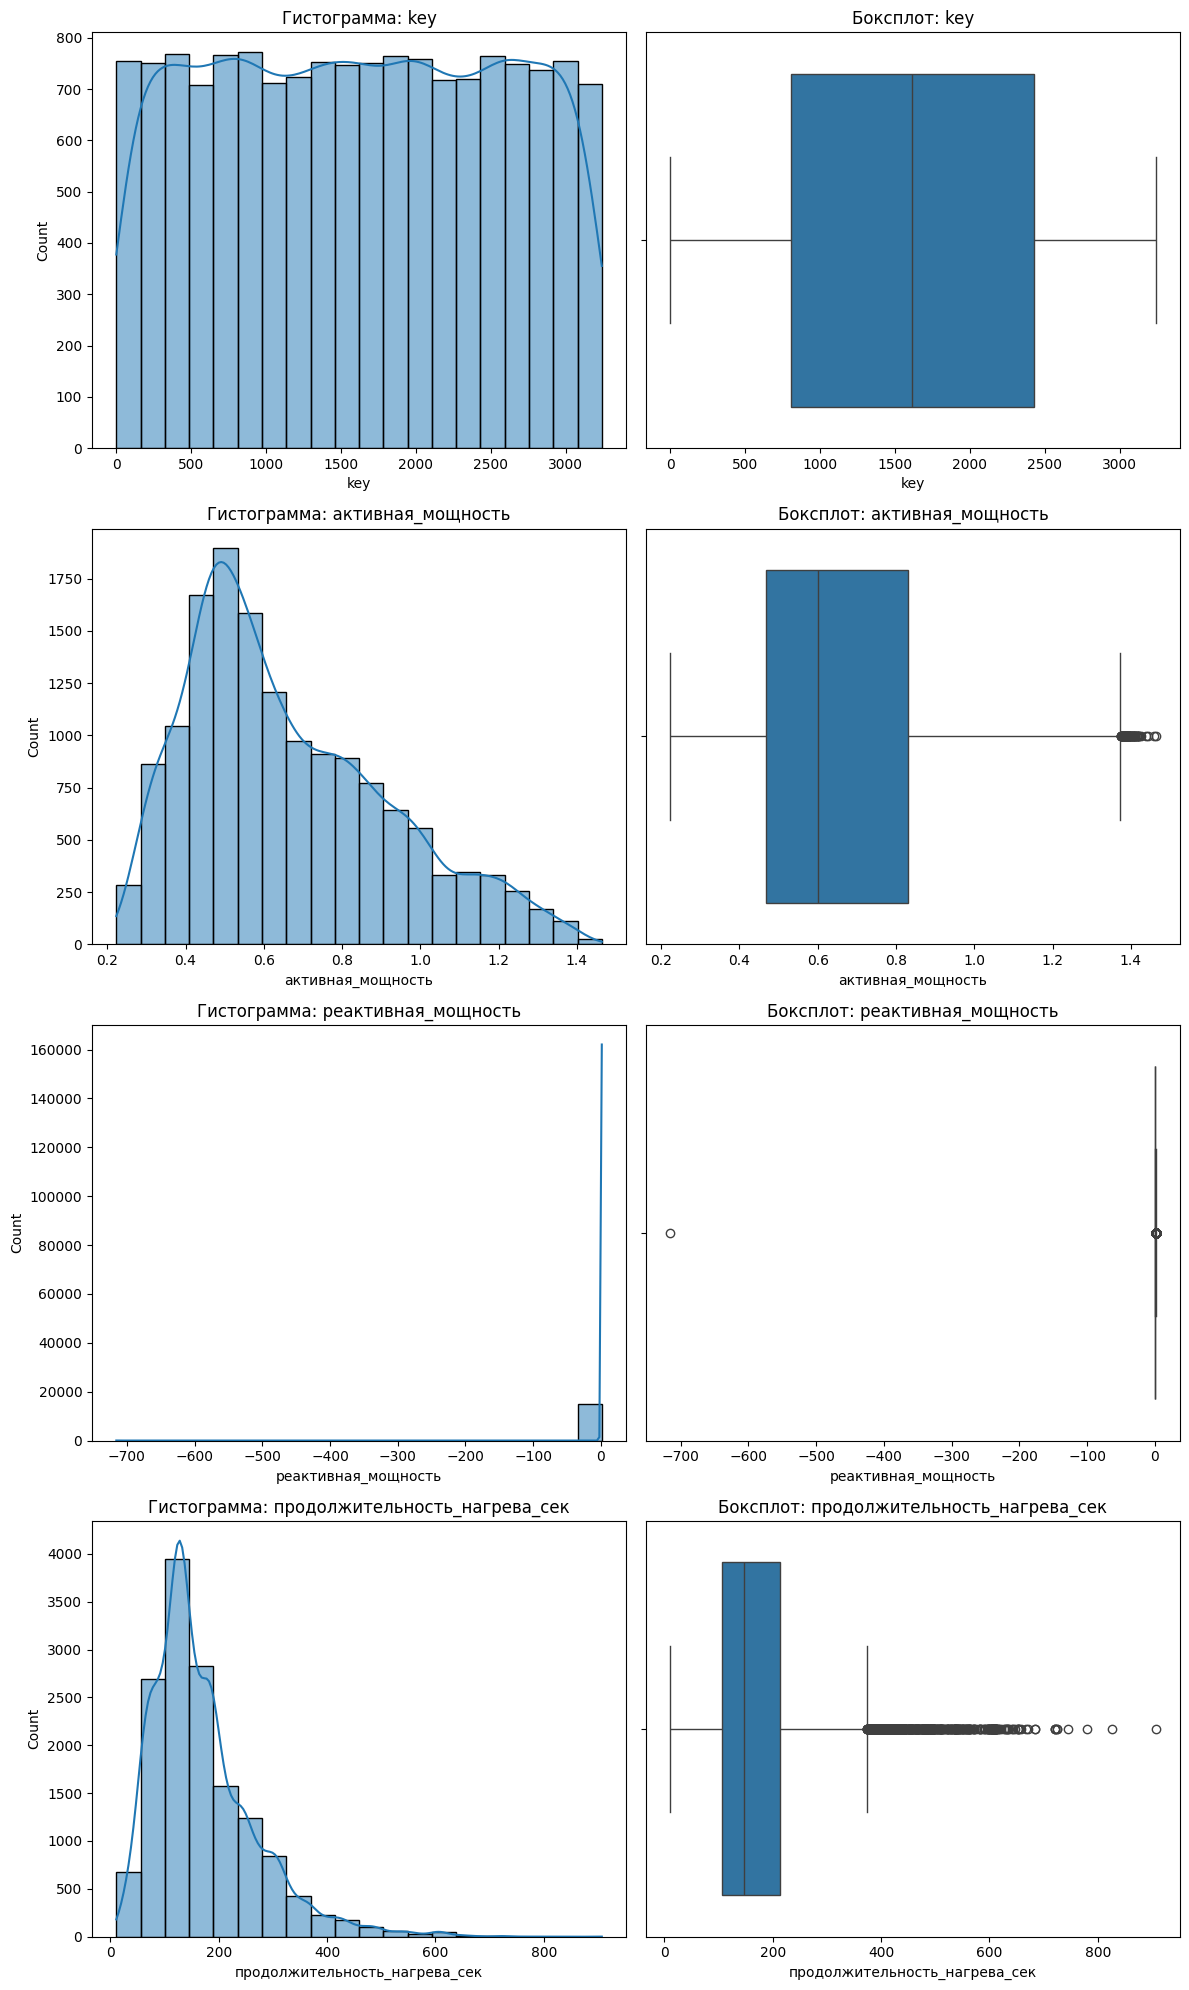

In [12]:
# теперь посмотрим распределение данных
plot_combined(df_arc, col=None, target=None, col_type=None, legend_loc='best')

Везде наблюдаем наличие сильных выбросов, проверим детальнее

In [13]:
df_arc[df_arc['активная_мощность'] > 1.3]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек
171,38,2019-05-04 17:18:40,2019-05-04 17:21:07,1.336674,1.213404,147.0
296,64,2019-05-05 22:47:19,2019-05-05 22:49:19,1.316444,1.054070,120.0
331,70,2019-05-06 04:00:31,2019-05-06 04:02:06,1.341706,0.950409,95.0
493,106,2019-05-07 08:16:16,2019-05-07 08:21:28,1.327936,0.969106,312.0
517,113,2019-05-07 15:41:34,2019-05-07 15:43:52,1.317665,0.945464,138.0
...,...,...,...,...,...,...
14368,3123,2019-09-02 16:59:39,2019-09-02 17:00:40,1.330737,0.915607,61.0
14549,3166,2019-09-03 22:18:01,2019-09-03 22:20:04,1.368719,1.083031,123.0
14577,3172,2019-09-04 05:58:03,2019-09-04 06:03:15,1.316411,0.886694,312.0
14775,3219,2019-09-05 21:47:29,2019-09-05 21:51:18,1.347920,1.025508,229.0


Значения увеличиваются равномерно и постепенно, сложно сказать ошибка это или нет

In [14]:
df_arc[df_arc['реактивная_мощность'] < 0]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924,109.0


Явная ошибка заполнения данных, посчитаем среднюю активная_мощность и среднюю реактивная_мощность  
Посмотрим коэффицент изменения и изменим эту ошибку соответственно

In [15]:
avg_act_power = df_arc['активная_мощность'].mean()
avg_react_power = df_arc['реактивная_мощность'].mean()
koef_power = (avg_act_power / avg_react_power) - 1
logger.info(avg_act_power)
logger.info(avg_react_power)
logger.info(koef_power)


2026-03-02 18:51:04 [INFO] __main__: 0.6627522122882497
2026-03-02 18:51:04 [INFO] __main__: 0.43898642672761495
2026-03-02 18:51:04 [INFO] __main__: 0.5097328116239874


In [16]:
df_arc.loc[df_arc['реактивная_мощность'] < 0, 'реактивная_мощность'] = df_arc['активная_мощность'] * koef_power

In [17]:
df_arc[df_arc['продолжительность_нагрева_сек'] > 400]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек
20,5,2019-05-03 13:23:32,2019-05-03 13:30:27,0.461620,0.308665,415.0
30,8,2019-05-03 14:53:56,2019-05-03 15:01:11,0.401980,0.292894,435.0
94,21,2019-05-04 03:42:26,2019-05-04 03:52:24,0.639156,0.425871,598.0
137,30,2019-05-04 10:49:25,2019-05-04 10:56:44,0.782927,0.546200,439.0
145,32,2019-05-04 12:58:33,2019-05-04 13:07:22,0.502953,0.352604,529.0
...,...,...,...,...,...,...
14654,3188,2019-09-04 20:54:34,2019-09-04 21:01:49,0.315474,0.254738,435.0
14659,3189,2019-09-04 22:29:02,2019-09-04 22:35:47,1.012875,0.772938,405.0
14772,3218,2019-09-05 20:49:26,2019-09-05 20:57:17,1.281652,1.074167,471.0
14779,3220,2019-09-05 22:35:56,2019-09-05 22:43:26,0.994169,0.720291,450.0


Здесь как буд-то бы тоже всё ок по времени, надо детальнее изучать вопрос относительно нормальности плавки

In [18]:
# добавим немного новых фич
df_arc['полная_мощность'] = np.sqrt(df_arc['активная_мощность']**2 + df_arc['реактивная_мощность']**2)
df_arc['соотношение_мощностей'] = df_arc['реактивная_мощность'] / df_arc['активная_мощность']
df_arc['cos_phi'] = 1 / np.sqrt(1 + df_arc['соотношение_мощностей']**2)

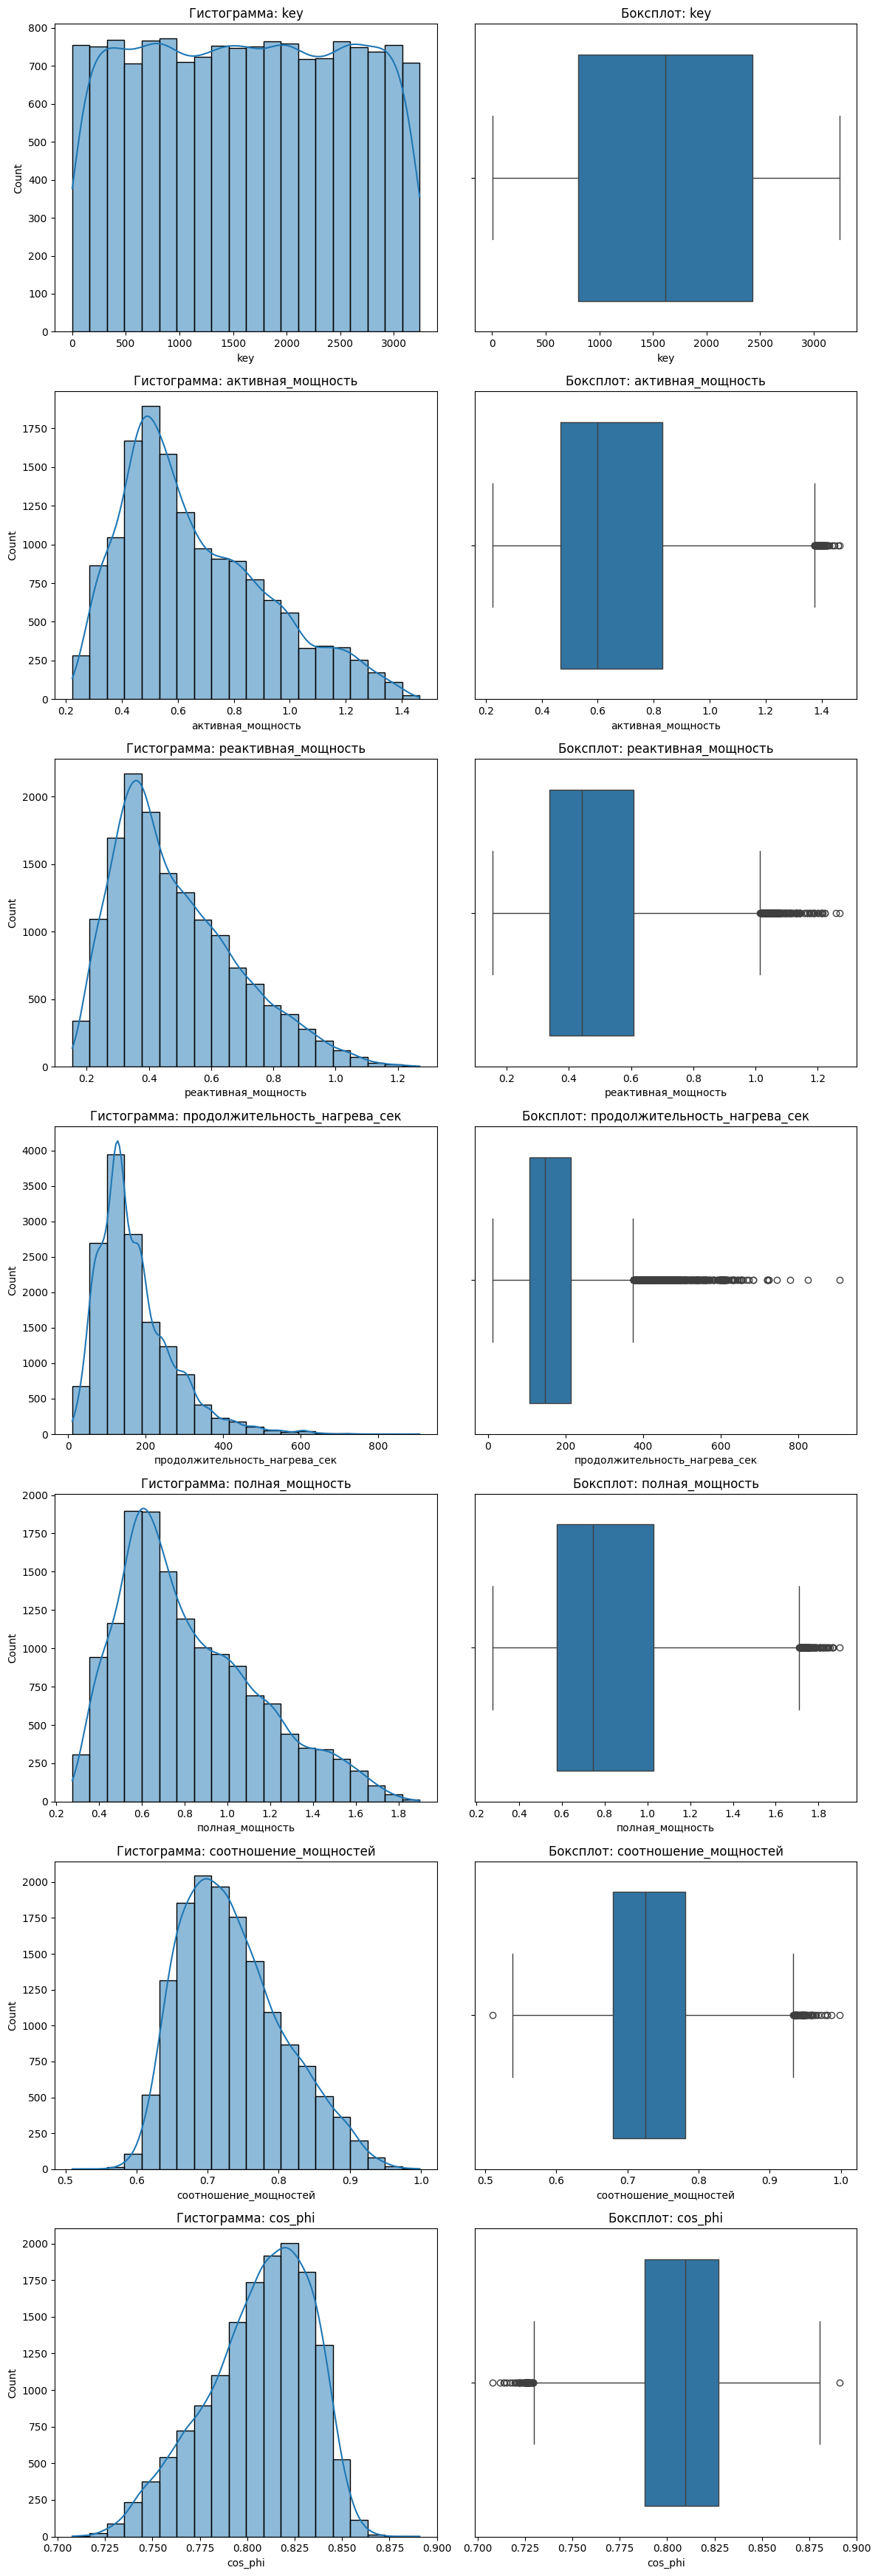

In [19]:
# теперь посмотрим распределение данных
plot_combined(df_arc, col=None, target=None, col_type=None, legend_loc='best')

In [22]:
display(df_arc.info())
display(df_arc.head())
display(df_arc.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   key                            14876 non-null  int64         
 1   начало_нагрева_дугой           14876 non-null  datetime64[ns]
 2   конец_нагрева_дугой            14876 non-null  datetime64[ns]
 3   активная_мощность              14876 non-null  float64       
 4   реактивная_мощность            14876 non-null  float64       
 5   продолжительность_нагрева_сек  14876 non-null  float64       
 6   полная_мощность                14876 non-null  float64       
 7   соотношение_мощностей          14876 non-null  float64       
 8   cos_phi                        14876 non-null  float64       
dtypes: datetime64[ns](2), float64(6), int64(1)
memory usage: 1.0 MB


None

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек,полная_мощность,соотношение_мощностей,cos_phi
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,0.371123,0.692338,0.822181
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,0.902319,0.623566,0.848545
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,0.722536,0.741772,0.803161
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,365.0,0.642824,0.732848,0.806591
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,148.0,1.079934,0.742321,0.802950


,count,mean,min,25%,50%,75%,max,std
key,14876.0,1615.220422,1.0,806.0,1617.0,2429.0,3241.0,934.571502
начало_нагрева_дугой,14876,2019-07-05 12:25:51.921081088,2019-05-03 11:02:14,2019-06-03 23:18:23.249999872,2019-07-03 01:31:26.500000,2019-08-07 22:52:20.750000128,2019-09-06 17:24:54,NaN
конец_нагрева_дугой,14876,2019-07-05 12:28:43.592027392,2019-05-03 11:06:02,2019-06-03 23:21:35,2019-07-03 01:35:13,2019-08-07 22:56:47,2019-09-06 17:26:15,NaN
активная_мощность,14876.0,0.662752,0.22312,0.467115,0.599587,0.83007,1.463773,0.258885
реактивная_мощность,14876.0,0.487107,0.153777,0.337192,0.441639,0.608201,1.270284,0.197609
продолжительность_нагрева_сек,14876.0,171.670946,11.0,107.0,147.0,214.0,907.0,98.186803
полная_мощность,14876.0,0.823382,0.275718,0.578847,0.746591,1.03039,1.898158,0.323459
соотношение_мощностей,14876.0,0.734908,0.509733,0.679707,0.724754,0.781162,0.998261,0.072438
cos_phi,14876.0,0.805893,0.707722,0.788058,0.809705,0.827039,0.890932,0.027664


##### df_bulk

In [ ]:
df_bulk = check_data(df_bulk)

Много пропусков - но это мелочи.  
Заменим потом на 0, т.к. это просто означает, что не было подачи сыпучего материала

##### df_bulk_time

In [ ]:
df_bulk_time = check_data(df_bulk_time)

Аналогично и тут пропуски - время подачи, т.к. не было подачи по факту то и не было фиксации времени  
Здесь видимо пропуски так и останутся, решим попозже как правильно поступить

##### df_gas

In [ ]:
df_gas = check_data(df_gas)

Тут на первый взгляд все у нас хорошо

##### df_temp

In [ ]:
df_temp = check_data(df_temp)

У времени сделать нормальный тип данных  
Пропуски заменить на -1, т.к. пропустили замеры температуры и мы не сможем достоверно ее вычеслить  
Как эксперимент можем взять два соседних тайминга и просто взять среднюю между этими числами, критической проблемы тут быть не должно  
PS: изучив данные мы видим, что там на каждый key только один замер температуры, поэтому будет -1

##### df_wire

In [ ]:
df_wire = check_data(df_wire)

##### df_wire_time

In [ ]:
df_wire_time = check_data(df_wire_time)